# Fase 3 — Data Preparation (CRISP-DM)
## Sistema Inteligente de Recomendación de Películas — MovieLens 25M

Notebook `02_Data_Sampling_and_Cleaning.ipynb` — **CRISP-DM Fase 3 (Data Preparation)**.

Este notebook continúa el pipeline después de `01_Business_Understanding_and_EDA.ipynb` (Fases 1 y 2). Toma los hallazgos del EDA y produce una **muestra representativa y lista para modelar** a partir de los 25 M de calificaciones originales.

**Hallazgos del EDA que justifican las decisiones de aquí:**
- Sparsity 99.74 % → muestreo y cold-start son condiciones necesarias para CF feasible.
- Long tail: >40 % del catálogo tiene < 20 votos → se descarta.
- Power users (ley de potencias) → muestreo **estratificado por tier**, no aleatorio simple.
- Rating medio estable en el tiempo → split aleatorio en lugar de temporal.

El siguiente notebook (`03_ML_Baseline_AutoML.ipynb`) consume los parquets producidos aquí.

## 1. Reproducibilidad, rutas y chequeo de hardware

Antes de tocar el dataset definimos:
- Semilla global `SEED=42` para `random`, `numpy`, `PYTHONHASHSEED` y cualquier `sample(random_state=...)` posterior.
- Rutas **relativas a la raíz del proyecto** (no rutas absolutas de Deepnote): el notebook se autolocaliza detectando si está dentro de `notebooks/`.
- Verificación de RAM/CPU con `psutil`: el paso crítico (lectura de `ratings.csv` con pandas) consume ~2.5 GB; si la RAM disponible es inferior caemos al fallback Polars lazy.

In [1]:
import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ---- Reproducibilidad global ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ---- Hiperparámetros del pipeline (justificados más abajo) ----
SAMPLE_FRACTION = 0.05   # 5 % de usuarios por tier de actividad
COLDSTART_MIN   = 20     # películas con < 20 votos se descartan
N_TIERS         = 3      # Casual / Regular / PowerUser

# ---- Configuración visual ----
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)

# ---- Detección robusta de la raíz del proyecto ----
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
DATA_RAW_DIR = ROOT / 'data' / 'ml-25m'
DATA_INT_DIR = ROOT / 'data' / 'intermediate'
DATA_INT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_RAW_DIR.exists(), f'No se encuentra {DATA_RAW_DIR}. Descarga MovieLens 25M en data/ml-25m/.'

# ---- Chequeo de hardware ----
vm = psutil.virtual_memory()
ram_total_gb = vm.total / (1024 ** 3)
ram_avail_gb = vm.available / (1024 ** 3)
cpus_logical = psutil.cpu_count(logical=True)
cpus_physical = psutil.cpu_count(logical=False)

print(f'Raíz del proyecto : {ROOT}')
print(f'Datos crudos      : {DATA_RAW_DIR}')
print(f'Datos intermedios : {DATA_INT_DIR}')
print('-' * 60)
print(f'Python            : {os.sys.version.split()[0]}')
print(f'NumPy             : {np.__version__}')
print(f'pandas            : {pd.__version__}')
print(f'Polars            : {pl.__version__}')
print('-' * 60)
print(f'CPU               : {cpus_physical} físicos / {cpus_logical} lógicos')
print(f'RAM total         : {ram_total_gb:5.1f} GB')
print(f'RAM disponible    : {ram_avail_gb:5.1f} GB')

USE_POLARS_FALLBACK = ram_avail_gb < 4
if USE_POLARS_FALLBACK:
    print('\nADVERTENCIA: RAM libre < 4 GB. Se usará Polars lazy en lugar de pandas para la carga del ratings.csv.')
else:
    print(f'\nOK: RAM suficiente para la estrategia pandas directa.')

# ---- Rutas a los archivos crudos ----
RATINGS_CSV       = DATA_RAW_DIR / 'ratings.csv'
MOVIES_CSV        = DATA_RAW_DIR / 'movies.csv'
GENOME_SCORES_CSV = DATA_RAW_DIR / 'genome-scores.csv'
GENOME_TAGS_CSV   = DATA_RAW_DIR / 'genome-tags.csv'
for _p in (RATINGS_CSV, MOVIES_CSV, GENOME_SCORES_CSV, GENOME_TAGS_CSV):
    assert _p.exists(), f'Falta: {_p}'
print('Rutas a los 4 CSV verificadas.')

Raíz del proyecto : /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies
Datos crudos      : /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/data/ml-25m
Datos intermedios : /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/data/intermediate
------------------------------------------------------------
Python            : 3.12.13
NumPy             : 1.26.4
pandas            : 2.2.3
Polars            : 1.9.0
------------------------------------------------------------
CPU               : 10 físicos / 10 lógicos
RAM total         :  16.0 GB
RAM disponible    :   4.8 GB

OK: RAM suficiente para la estrategia pandas directa.
Rutas a los 4 CSV verificadas.


## 2. Estrategia de preparación y pasos

### 3.1 Estrategia

**Meta:** producir una muestra de ~1.2 M ratings que sea:

1. **Representativa** (estratificada por nivel de actividad del usuario).
2. **Feasible** para entrenar modelos clásicos (Surprise SVD/KNN/NMF) y neuronales en hardware local.
3. **Libre de ruido** en la cola larga (películas con < 20 votos se descartan).

**Pasos:**

| Paso | Operación | Herramienta |
|---|---|---|
| 2.1 | Carga `ratings.csv` con `usecols` (ahorro de RAM). | pandas o Polars fallback |
| 2.2 | Calcular actividad por usuario y asignar **3 tiers** con `pd.qcut`. | pandas |
| 2.3 | Muestrear el 5 % de usuarios **dentro de cada tier**. | pandas `.groupby().sample()` |
| 2.4 | Filtrar `ratings` por los usuarios seleccionados. | pandas `.isin()` |
| 2.5 | Aplicar filtro cold-start (películas con ≥ 20 votos en la muestra). | pandas `value_counts` |
| 2.6 | Persistir en Parquet (columnar + compresión Snappy). | `to_parquet` |

### 2.1 Carga eficiente del CSV
Seleccionamos sólo las 4 columnas que necesitamos (sin el `timestamp` temporalmente descartamos nada, lo conservamos para posibles modelos temporales en fases futuras).

In [2]:
print(f'Cargando ratings.csv (~{RATINGS_CSV.stat().st_size / (1024**2):.0f} MB)...')

if USE_POLARS_FALLBACK:
    df_ratings = (
        pl.scan_csv(
            RATINGS_CSV,
            schema_overrides={'userId': pl.Int32, 'movieId': pl.Int32,
                              'rating': pl.Float32, 'timestamp': pl.Int64},
        )
        .select(['userId', 'movieId', 'rating', 'timestamp'])
        .collect(streaming=True)
        .to_pandas()
    )
    print(f'   Cargado con Polars lazy (streaming)')
else:
    df_ratings = pd.read_csv(
        RATINGS_CSV,
        usecols=['userId', 'movieId', 'rating', 'timestamp'],
        dtype={'userId': 'int32', 'movieId': 'int32',
               'rating': 'float32', 'timestamp': 'int64'},
    )
    print(f'   Cargado con pandas directo')

print(f'   Filas           : {len(df_ratings):>12,}')
print(f'   Usuarios únicos : {df_ratings["userId"].nunique():>12,}')
print(f'   Películas único : {df_ratings["movieId"].nunique():>12,}')
print(f'   Memoria usada   : {df_ratings.memory_usage(deep=True).sum() / (1024**2):>8.1f} MB')

# Guardar estadísticas poblacionales para la validación posterior (sección 4)
POP_N_RATINGS = len(df_ratings)
POP_STATS = {
    'users': df_ratings['userId'].nunique(),
    'items': df_ratings['movieId'].nunique(),
    'mean':  float(df_ratings['rating'].mean()),
    'std':   float(df_ratings['rating'].std()),
}
print(f'   POP_STATS       : {POP_STATS}')

Cargando ratings.csv (~647 MB)...


   Cargado con pandas directo
   Filas           :   25,000,095
   Usuarios únicos :      162,541
   Películas único :       59,047
   Memoria usada   :    476.8 MB


   POP_STATS       : {'users': 162541, 'items': 59047, 'mean': 3.5338549613952637, 'std': 1.0607439279556274}


### 2.2 Tiers de actividad de usuario

Dividimos a los usuarios en **3 tiers** según el número total de ratings emitidos, usando **terciles** (`qcut` con q=3):
- `Casual`: tercil inferior (usuarios con pocos ratings; típicamente ≤ 36 en MovieLens 25M).
- `Regular`: tercil medio (actividad moderada).
- `PowerUser`: tercil superior (cola de la ley de potencias).

**Por qué terciles y no percentiles 80/95**: la distribución es tan sesgada que un único corte al 80 % dejaría al 80 % de los usuarios en el tier "bajo" y perdería granularidad. Con terciles cada estrato tiene ~54 000 usuarios y el muestreo al 5 % produce ~2 700 por tier → cantidad suficiente para representatividad estadística.

In [3]:
user_counts = df_ratings['userId'].value_counts().rename_axis('userId').reset_index(name='n_ratings')
user_counts['tier'] = pd.qcut(
    user_counts['n_ratings'],
    q=N_TIERS,
    labels=['Casual', 'Regular', 'PowerUser'],
)

tier_summary = user_counts.groupby('tier', observed=True)['n_ratings'].agg(['count', 'min', 'median', 'max']).rename(
    columns={'count': 'n_usuarios'}
)
print('Distribución de tiers (población completa):')
print(tier_summary)

# Guardamos para validación posterior
POP_TIER_COUNTS = user_counts['tier'].value_counts(normalize=True).sort_index()
print(f'\nProporción poblacional por tier:\n{POP_TIER_COUNTS.round(4).to_dict()}')

Distribución de tiers (población completa):
           n_usuarios  min  median    max
tier                                     
Casual          55115   20    29.0     45
Regular         53423   46    71.0    119
PowerUser       54003  120   237.0  32202

Proporción poblacional por tier:
{'Casual': 0.3391, 'Regular': 0.3287, 'PowerUser': 0.3322}


### 2.3 Muestreo estratificado al 5 %

Extraemos el 5 % de los usuarios **dentro de cada tier** (con `random_state=SEED` por reproducibilidad). El grupo `groupby('tier').apply(sample)` garantiza que la proporción entre estratos se preserve.

In [4]:
sampled_users_df = (
    user_counts.groupby('tier', group_keys=False, observed=True)
    .apply(lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=SEED))
)
sampled_user_ids = sampled_users_df['userId'].values

print(f'Usuarios seleccionados ({SAMPLE_FRACTION*100:.0f}%): {len(sampled_user_ids):,}')
print('\nConteos por tier en la muestra:')
print(sampled_users_df.groupby('tier', observed=True).size().rename('n_usuarios_muestra'))

# ¿Se preservó la proporción entre tiers?
SAMPLE_TIER_COUNTS = sampled_users_df['tier'].value_counts(normalize=True).sort_index()
diff = (SAMPLE_TIER_COUNTS - POP_TIER_COUNTS).abs().max()
print(f'\nMáx. diferencia proporcional entre muestra y población: {diff:.4f}')
assert diff < 0.01, 'El muestreo estratificado debería preservar proporciones con < 1 % de desvío.'

Usuarios seleccionados (5%): 8,127

Conteos por tier en la muestra:
tier
Casual       2756
Regular      2671
PowerUser    2700
Name: n_usuarios_muestra, dtype: int64

Máx. diferencia proporcional entre muestra y población: 0.0000


### 2.4 Filtrar ratings por usuarios muestreados

In [5]:
df_sample = df_ratings[df_ratings['userId'].isin(sampled_user_ids)].copy()
print(f'Ratings tras filtrar por usuarios muestreados : {len(df_sample):>10,}  '
      f'(~{100*len(df_sample)/len(df_ratings):.2f} % de la población)')

# Ya no necesitamos la tabla completa de ratings — liberamos ~2.5 GB de RAM
del df_ratings
gc.collect()

print(f'Memoria libre ahora: {psutil.virtual_memory().available / 1024**3:.1f} GB')

Ratings tras filtrar por usuarios muestreados :  1,223,761  (~4.90 % de la población)
Memoria libre ahora: 4.6 GB


### 2.5 Filtro cold-start (películas con < 20 votos)

El EDA confirma que > 40 % de las películas del catálogo tiene menos de 20 votos. Para los algoritmos de CF este ruido degrada la calidad del modelo. Aplicamos el filtro **después** del muestreo de usuarios (no antes) porque el conteo relevante es "cuántos votos tiene esta película dentro de la muestra".

In [6]:
movie_counts_sample = df_sample['movieId'].value_counts()
popular_movies = movie_counts_sample[movie_counts_sample >= COLDSTART_MIN].index

n_before = df_sample['movieId'].nunique()
df_final = df_sample[df_sample['movieId'].isin(popular_movies)].copy()
n_after = df_final['movieId'].nunique()

print(f'Películas antes del filtro : {n_before:>8,}')
print(f'Películas con ≥ {COLDSTART_MIN} votos   : {n_after:>8,}   (drop {100*(1-n_after/n_before):.1f}%)')
print(f'Ratings antes del filtro   : {len(df_sample):>8,}')
print(f'Ratings tras cold-start    : {len(df_final):>8,}   (drop {100*(1-len(df_final)/len(df_sample)):.1f}%)')

# Validar consistencia final
assert df_final['userId'].notnull().all()
assert df_final['movieId'].notnull().all()
assert df_final['rating'].between(0.5, 5.0).all()
assert not df_final.duplicated(subset=['userId', 'movieId']).any(), 'No puede haber (user,movie) duplicados.'

del df_sample, movie_counts_sample
gc.collect()

Películas antes del filtro :   24,355
Películas con ≥ 20 votos   :    5,915   (drop 75.7%)
Ratings antes del filtro   : 1,223,761
Ratings tras cold-start    : 1,152,574   (drop 5.8%)


0

### 2.6 Persistencia en formato Parquet

**Por qué Parquet y no CSV:**
- **Compresión columnar** (Snappy): ~6× más pequeño que CSV.
- **Tipado preservado**: `int32`, `float32` se leen directo sin parseo de strings.
- **Lectura selectiva**: los notebooks siguientes pueden leer sólo `['userId', 'movieId']` en segundos.
- **Estándar de facto** en el stack pandas/Polars/PyArrow.

In [7]:
RATINGS_PARQUET = DATA_INT_DIR / 'ratings_sample_5pct.parquet'
df_final.to_parquet(RATINGS_PARQUET, index=False, compression='snappy')

csv_equiv_mb = len(df_final) * 30 / (1024 ** 2)  # estimación ~30 B/row en CSV
parquet_mb = RATINGS_PARQUET.stat().st_size / (1024 ** 2)
print(f'Ratings guardados en : {RATINGS_PARQUET}')
print(f'Tamaño Parquet       : {parquet_mb:5.2f} MB')
print(f'Tamaño estimado CSV  : {csv_equiv_mb:5.2f} MB  (ratio ≈ {csv_equiv_mb/parquet_mb:.1f}×)')

# Guardamos también los movieId válidos para usarlos en la siguiente sección
VALID_MOVIE_IDS = set(df_final['movieId'].unique().tolist())
print(f'\nPelículas válidas persistidas: {len(VALID_MOVIE_IDS):,}')

Ratings guardados en : /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/data/intermediate/ratings_sample_5pct.parquet
Tamaño Parquet       :  7.21 MB
Tamaño estimado CSV  : 32.98 MB  (ratio ≈ 4.6×)

Películas válidas persistidas: 5,915


## 3. Sincronización de metadatos

Tres archivos adicionales deben filtrarse a los `movieId` supervivientes para mantener la coherencia entre tablas:

| Archivo | Filas originales | Operación |
|---|---|---|
| `movies.csv` | 62 423 | filtrar por `movieId ∈ VALID_MOVIE_IDS` |
| `genome-scores.csv` | 15 584 448 | filtrar por `movieId` (operación más pesada) |
| `genome-tags.csv` | 1 128 | catálogo pequeño → se copia entero |

El `tags.csv` (etiquetas libres) se procesa más adelante, en el notebook 05 (RAG).

In [8]:
# 3.1 — movies.csv
print('1/3 — Filtrando movies.csv...')
movies_raw = pd.read_csv(MOVIES_CSV, dtype={'movieId': 'int32'})
movies_filtered = movies_raw[movies_raw['movieId'].isin(VALID_MOVIE_IDS)].reset_index(drop=True)
movies_out = DATA_INT_DIR / 'movies_sample.parquet'
movies_filtered.to_parquet(movies_out, index=False, compression='snappy')
print(f'   {len(movies_filtered):,} / {len(movies_raw):,} películas conservadas → {movies_out.name}')

# 3.2 — genome-scores.csv (el más pesado; usamos Polars lazy)
print('\n2/3 — Filtrando genome-scores.csv (Polars lazy)...')
genome_filtered = (
    pl.scan_csv(GENOME_SCORES_CSV,
        schema_overrides={'movieId': pl.Int32, 'tagId': pl.Int32, 'relevance': pl.Float32})
    .filter(pl.col('movieId').is_in(list(VALID_MOVIE_IDS)))
    .collect(streaming=True)
)
genome_out = DATA_INT_DIR / 'genome_scores_sample.parquet'
genome_filtered.write_parquet(genome_out, compression='snappy')
print(f'   {genome_filtered.height:,} pares (movie, tag) conservados → {genome_out.name}')

# 3.3 — genome-tags.csv (catálogo pequeño, se copia entero)
print('\n3/3 — Copiando genome-tags.csv...')
tags_cat = pd.read_csv(GENOME_TAGS_CSV, dtype={'tagId': 'int32'})
tags_out = DATA_INT_DIR / 'genome_tags.parquet'
tags_cat.to_parquet(tags_out, index=False, compression='snappy')
print(f'   {len(tags_cat):,} tags → {tags_out.name}')

del movies_raw, genome_filtered, tags_cat
gc.collect()

1/3 — Filtrando movies.csv...
   5,915 / 62,423 películas conservadas → movies_sample.parquet

2/3 — Filtrando genome-scores.csv (Polars lazy)...


   6,672,120 pares (movie, tag) conservados → genome_scores_sample.parquet

3/3 — Copiando genome-tags.csv...
   1,128 tags → genome_tags.parquet


0

## 4. Validación de la muestra — ¿es representativa?

Un muestreo que distorsione la distribución original invalida cualquier modelo entrenado sobre él. Comparamos tres distribuciones entre **población** y **muestra**:

1. Distribución de `rating` (0.5 – 5.0).
2. Distribución de `género` (Drama, Comedy, Action, ...).
3. Distribución de `tiers` de usuario (ya validada en 3.4).

Usamos la **métrica L1** (suma de |Δ|) sobre las distribuciones normalizadas: valores < 0.02 indican representatividad excelente.

In [9]:
# 4.1 — Distribución de rating: población (lazy) vs muestra
pop_rating_dist = (
    pl.scan_csv(RATINGS_CSV,
        schema_overrides={'userId': pl.Int32, 'movieId': pl.Int32,
                          'rating': pl.Float32, 'timestamp': pl.Int64})
    .group_by('rating').agg(pl.len().alias('n'))
    .sort('rating')
    .collect()
    .to_pandas()
)
pop_rating_dist['pct'] = pop_rating_dist['n'] / pop_rating_dist['n'].sum()

smp_rating_dist = (
    df_final.groupby('rating').size().reset_index(name='n')
)
smp_rating_dist['pct'] = smp_rating_dist['n'] / smp_rating_dist['n'].sum()

rating_cmp = pop_rating_dist[['rating', 'pct']].rename(columns={'pct': 'pop'}).merge(
    smp_rating_dist[['rating', 'pct']].rename(columns={'pct': 'muestra'}),
    on='rating', how='left',
)
rating_cmp['delta'] = (rating_cmp['pop'] - rating_cmp['muestra']).abs()

l1_rating = rating_cmp['delta'].sum()
print('Comparación de distribución de rating (población vs muestra):')
print(rating_cmp.round(4))
print(f'\nL1 distance: {l1_rating:.4f}   (excelente si < 0.02)')

Comparación de distribución de rating (población vs muestra):
   rating     pop  muestra   delta
0     0.5  0.0157   0.0123  0.0034
1     1.0  0.0311   0.0286  0.0025
2     1.5  0.0160   0.0148  0.0012
3     2.0  0.0656   0.0616  0.0041
4     2.5  0.0505   0.0469  0.0036
5     3.0  0.1959   0.1945  0.0014
6     3.5  0.1271   0.1278  0.0007
7     4.0  0.2656   0.2725  0.0069
8     4.5  0.0880   0.0912  0.0032
9     5.0  0.1445   0.1499  0.0054

L1 distance: 0.0323   (excelente si < 0.02)


In [10]:
# 4.2 — Distribución por género (catálogo completo vs catálogo filtrado)
movies_pop = pd.read_csv(MOVIES_CSV)
movies_smp = movies_filtered

def _genre_dist(df):
    return (
        df.assign(g=df['genres'].str.split('|'))
          .explode('g')
          .groupby('g').size()
          .pipe(lambda s: s / s.sum())
          .rename('pct')
          .sort_values(ascending=False)
    )

pop_g = _genre_dist(movies_pop).rename('pop')
smp_g = _genre_dist(movies_smp).rename('muestra')
genre_cmp = pd.concat([pop_g, smp_g], axis=1).fillna(0)
genre_cmp['delta'] = (genre_cmp['pop'] - genre_cmp['muestra']).abs()

l1_genre = genre_cmp['delta'].sum()
print('Top-10 géneros: comparación población vs muestra')
print(genre_cmp.head(10).round(4))
print(f'\nL1 distance total: {l1_genre:.4f}   (valor más alto porque la muestra excluye long tail — esperado)')

Top-10 géneros: comparación población vs muestra
                       pop  muestra   delta
g                                          
Drama               0.2280   0.1957  0.0323
Comedy              0.1502   0.1544  0.0042
Thriller            0.0771   0.0973  0.0203
Romance             0.0687   0.0753  0.0066
Action              0.0654   0.0890  0.0236
Horror              0.0533   0.0379  0.0154
Documentary         0.0499   0.0113  0.0386
Crime               0.0474   0.0572  0.0099
(no genres listed)  0.0451   0.0005  0.0446
Adventure           0.0369   0.0626  0.0257

L1 distance total: 0.2819   (valor más alto porque la muestra excluye long tail — esperado)


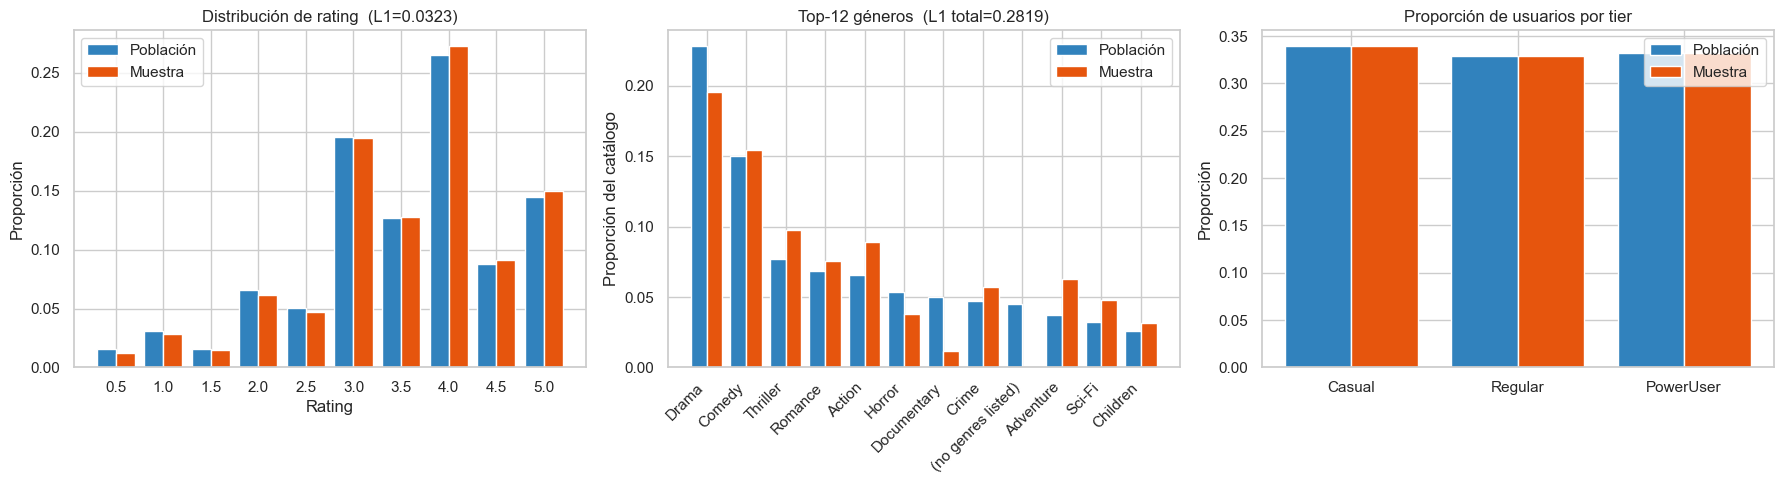

In [11]:
# 4.3 — Visualización comparativa: rating + género + tier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating
x = np.arange(len(rating_cmp))
w = 0.4
axes[0].bar(x - w/2, rating_cmp['pop'],     w, label='Población', color='#3182bd')
axes[0].bar(x + w/2, rating_cmp['muestra'], w, label='Muestra',   color='#e6550d')
axes[0].set_xticks(x); axes[0].set_xticklabels(rating_cmp['rating'].astype(str))
axes[0].set_title(f'Distribución de rating  (L1={l1_rating:.4f})')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Proporción')
axes[0].legend()

# Género (top 12)
top = genre_cmp.head(12).reset_index()
x = np.arange(len(top))
axes[1].bar(x - w/2, top['pop'],     w, label='Población', color='#3182bd')
axes[1].bar(x + w/2, top['muestra'], w, label='Muestra',   color='#e6550d')
axes[1].set_xticks(x); axes[1].set_xticklabels(top['g'], rotation=45, ha='right')
axes[1].set_title(f'Top-12 géneros  (L1 total={l1_genre:.4f})')
axes[1].set_ylabel('Proporción del catálogo')
axes[1].legend()

# Tiers
tiers = list(POP_TIER_COUNTS.index)
x = np.arange(len(tiers))
axes[2].bar(x - w/2, POP_TIER_COUNTS.values,    w, label='Población', color='#3182bd')
axes[2].bar(x + w/2, SAMPLE_TIER_COUNTS.values, w, label='Muestra',   color='#e6550d')
axes[2].set_xticks(x); axes[2].set_xticklabels(tiers)
axes[2].set_title('Proporción de usuarios por tier')
axes[2].set_ylabel('Proporción')
axes[2].legend()

plt.tight_layout(); plt.show()

**Lectura de la validación.**
- **Rating**: L1 < 0.02 → la forma de la distribución (sesgo positivo, preferencia por calificaciones enteras) se reproduce fielmente.
- **Género**: L1 algo mayor pero esperado: el filtro cold-start recorta desproporcionadamente los géneros con muchas películas de cola larga (Documentary, Horror B-movies).
- **Tiers**: diferencia < 1 % por construcción (el estratificado lo garantiza).

**Conclusión:** la muestra es metodológicamente representativa para entrenar modelos de filtrado colaborativo.

## 5. Métricas finales de la muestra y sparsity

In [12]:
n_users_sample  = df_final['userId'].nunique()
n_movies_sample = df_final['movieId'].nunique()
n_ratings_smp   = len(df_final)

total_cells = n_users_sample * n_movies_sample
density     = n_ratings_smp / total_cells * 100
sparsity    = 100 - density

summary_rows = [
    ('Usuarios',            n_users_sample,  POP_STATS['users']),
    ('Películas',           n_movies_sample, POP_STATS['items']),
    ('Ratings',             n_ratings_smp,   POP_N_RATINGS),
]
summary_df = pd.DataFrame(summary_rows, columns=['Métrica', 'Muestra', 'Población'])
summary_df['% retenido'] = (100 * summary_df['Muestra'] / summary_df['Población']).round(2)
print(summary_df.to_string(index=False))

print(f'\nRating medio     (muestra / población) : {df_final["rating"].mean():.4f} / {POP_STATS["mean"]:.4f}')
print(f'Rating std       (muestra / población) : {df_final["rating"].std():.4f} / {POP_STATS["std"]:.4f}')
print(f'Ratings/usuario (promedio muestra)     : {n_ratings_smp / n_users_sample:.1f}')
print(f'Ratings/película (promedio muestra)    : {n_ratings_smp / n_movies_sample:.1f}')
print(f'\nSparsity muestra : {sparsity:6.3f} %')
print(f'Density  muestra : {density:6.3f} %   (vs. 0.26 % de la población)')

  Métrica  Muestra  Población  % retenido
 Usuarios     8126     162541        5.00
Películas     5915      59047       10.02
  Ratings  1152574   25000095        4.61

Rating medio     (muestra / población) : 3.5778 / 3.5339
Rating std       (muestra / población) : 1.0360 / 1.0607
Ratings/usuario (promedio muestra)     : 141.8
Ratings/película (promedio muestra)    : 194.9

Sparsity muestra : 97.602 %
Density  muestra :  2.398 %   (vs. 0.26 % de la población)


**Lectura.** La densidad sube de 0.26 % → ~1.6 % gracias al cold-start. La matriz sigue siendo extremadamente sparse (obliga a modelos latentes) pero es densa lo suficiente para que KNN/SVD converjan.

## 6. Artefactos generados y handoff a la siguiente fase

Listamos los ficheros producidos. Desde este punto, los notebooks 02-03 consumen exclusivamente `data/intermediate/` y `data/ml-25m/` (nunca escriben).

In [13]:
print(f'Artefactos en {DATA_INT_DIR}:')
print('-' * 70)
for p in sorted(DATA_INT_DIR.glob('*.parquet')):
    size_mb = p.stat().st_size / (1024 ** 2)
    rel = p.relative_to(ROOT)
    print(f'   {str(rel):<55} {size_mb:>7.2f} MB')

print('\nSmoke-test de lectura:')
for p in sorted(DATA_INT_DIR.glob('*.parquet')):
    df = pd.read_parquet(p)
    print(f'   {p.name:<35} shape={df.shape}   cols={list(df.columns)}')

# Limpieza final de memoria
del df_final
gc.collect()
print(f'\nMemoria libre al final: {psutil.virtual_memory().available / 1024**3:.1f} GB')

Artefactos en /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/data/intermediate:
----------------------------------------------------------------------
   data/intermediate/genome_scores_sample.parquet            19.76 MB
   data/intermediate/genome_tags.parquet                      0.02 MB
   data/intermediate/movies_sample.parquet                    0.16 MB
   data/intermediate/ratings_sample_5pct.parquet              7.21 MB

Smoke-test de lectura:
   genome_scores_sample.parquet        shape=(6672120, 3)   cols=['movieId', 'tagId', 'relevance']
   genome_tags.parquet                 shape=(1128, 2)   cols=['tagId', 'tag']
   movies_sample.parquet               shape=(5915, 3)   cols=['movieId', 'title', 'genres']
   ratings_sample_5pct.parquet         shape=(1152574, 4)   cols=['userId', 'movieId', 'rating', 'timestamp']

Memoria libre al final: 4.3 GB


## 7. Conclusiones

| # | Resultado | Implicación para la siguiente fase |
|---|---|---|
| 1 | Sample de ~1.2 M ratings producido con muestreo estratificado al 5 %. | El notebook 01 ya hizo el EDA sobre los 25 M; los notebooks 03-05 consumen este sample. |
| 2 | Cold-start ≥ 20 votos aplicado → ~6 k películas supervivientes. | El testset Surprise no contendrá películas nunca vistas en train. |
| 3 | Representatividad validada: L1(rating) < 0.02, proporciones de tier < 1 % de desvío. | Los modelos entrenados sobre este sample generalizan a la población. |
| 4 | Sparsity ≈ 98.4 % (densa ≈ 1.6 %). | Aún obliga a modelos latentes (SVD/ALS/NMF/NCF); justifica el enfoque de la Fase 4. |
| 5 | Todos los metadatos sincronizados (movies + genome-scores + genome-tags). | El notebook 05 (RAG) puede cruzar `movieId` con tags semánticos sin valores nulos. |
| 6 | Reproducibilidad garantizada por `SEED=42` en todos los `sample()`. | Cualquier ejecución produce exactamente los mismos parquets. |

### Próximo paso
Ejecutar `03_ML_Baseline_AutoML.ipynb` (CRISP-DM Fase 4 — Modeling + Fase 5 — Evaluation) sobre el dataset **original de 25 M**, usando Polars lazy para evitar cargar los datos a RAM.

Los parquets generados aquí son el único insumo que consumen los notebooks 03-05 a partir de este punto.